<a href="https://colab.research.google.com/github/CityScope/pyGTFSHandler/blob/main/examples/direction_conflicts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys, os

if "google.colab" in sys.modules:
    if not os.path.exists("pyGTFSHandler"):
        !git clone --depth 1 https://github.com/CityScope/pyGTFSHandler.git
    %cd pyGTFSHandler
    !pip install -q -e ".[plot,osm,geocoding]"
    %cd examples

# Direction & headway methodology

How pyGTFSHandler derives `direction_id` from geometry alone, and how it
summarizes a stop's departures into a single "headway" number. Small
synthetic examples throughout, no real-world feed required until the last
two sections.

1. Reconciling forward/backward bearings at a stop
2. Clustering bearings into direction bins (the "widest gap" split)
3. From per-stop bins to a route-wide `direction_id`
4. The headway formula
5. Worked example -- a genuine `direction_id` conflict
6. Worked example -- direction split & headway via the public `Feed` API


In [1]:
import datetime
import math
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from pyGTFSHandler import Feed
from pyGTFSHandler.models.shapes import _reconcile_fwd_bwd, _split_angle, _widest_gap_split
from pyGTFSHandler.utils.colors import CB_BLUE, CB_ORANGE, CB_GREEN, CB_VERMILLION, CB_SKY, CB_PURPLE, CB_YELLOW, CB_BLACK
from pyGTFSHandler.plots.example_notebooks import bearing_xy as bearing_to_xy, compute_headway, plot_widest_gap_compass


## 1. Reconciling forward/backward bearings

At a stop a shape merely passes through, its incoming ("forward") and
outgoing ("backward") bearings should be exactly 180 degrees apart, but
rarely are in practice (uneven `shape_pt_sequence` spacing, curved
segments, ...).

- `_reconcile_fwd_bwd(fwd, bwd)` rotates both bearings toward each other by
  the same amount, in opposite directions, until they're exactly 180
  degrees apart
- Neither raw reading is trusted over the other -- the correction is split
  50/50


In [2]:
examples = [
    (30.0, 100.0),
    (270.0, 300.0),
]

for fwd, bwd in examples:
    fwd_final, bwd_final = _reconcile_fwd_bwd(fwd, bwd)
    print(
        f"forward={fwd:6.1f}  backward={bwd:6.1f}   ->   "
        f"forward'={fwd_final:6.1f}  backward'={bwd_final:6.1f}   "
        f"(diff={((bwd_final - fwd_final) % 360):.1f}, "
        f"|Δforward|={abs(((fwd_final - fwd + 540) % 360) - 180):.1f}, "
        f"|Δbackward|={abs(((bwd_final - bwd + 540) % 360) - 180):.1f})"
    )


forward=  30.0  backward= 100.0   ->   forward'= 335.0  backward'= 155.0   (diff=180.0, |Δforward|=55.0, |Δbackward|=55.0)
forward= 270.0  backward= 300.0   ->   forward'= 195.0  backward'=  15.0   (diff=180.0, |Δforward|=75.0, |Δbackward|=75.0)


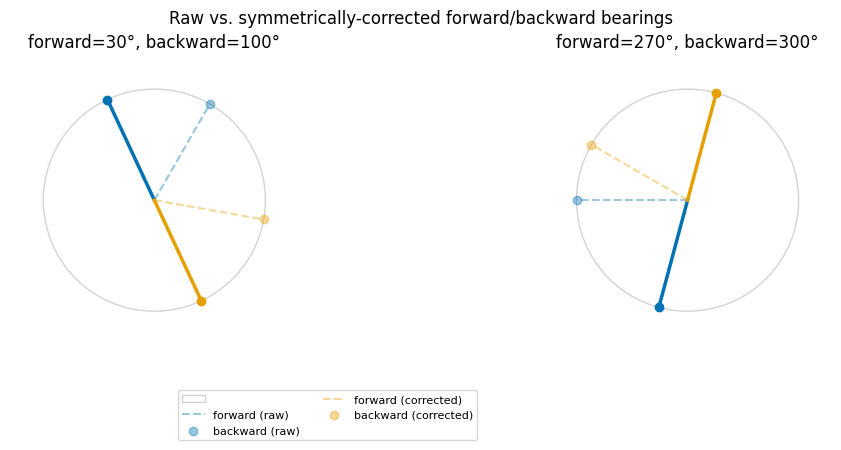

In [3]:
fig, axes = plt.subplots(1, len(examples), figsize=(9, 4.5), subplot_kw={"aspect": "equal"})

for ax, (fwd, bwd) in zip(axes, examples):
    fwd_final, bwd_final = _reconcile_fwd_bwd(fwd, bwd)

    circle = plt.Circle((0, 0), 1, fill=False, color="lightgray", linewidth=1)
    ax.add_patch(circle)

    for deg, color, label, style in [
        (fwd, CB_BLUE, "forward (raw)", "dashed"),
        (bwd, CB_ORANGE, "backward (raw)", "dashed"),
        (fwd_final, CB_BLUE, "forward (corrected)", "solid"),
        (bwd_final, CB_ORANGE, "backward (corrected)", "solid"),
    ]:
        x, y = bearing_to_xy(deg)
        alpha = 1.0 if style == "solid" else 0.4
        lw = 2.5 if style == "solid" else 1.5
        ax.plot([0, x], [0, y], color=color, linestyle=style, alpha=alpha, linewidth=lw)
        ax.scatter([x], [y], color=color, alpha=alpha, zorder=3)

    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_title(f"forward={fwd:.0f}°, backward={bwd:.0f}°")
    ax.axis("off")

axes[0].legend(
    ["", "forward (raw)", "backward (raw)", "forward (corrected)", "backward (corrected)"],
    loc="lower center", bbox_to_anchor=(1.1, -0.35), ncol=2, fontsize=8,
)
fig.suptitle("Raw vs. symmetrically-corrected forward/backward bearings")
plt.tight_layout()
plt.show()


## 2. Clustering bearings into direction bins

Once every shape has bearings at a stop, `_widest_gap_split` clusters them
into two local bins (0/1): find the widest gap between the observed
bearings on the compass circle, and split at that gap's midpoint.

- Each shape contributes **both** points of its corrected forward/backward
  pair, not just one
- This prevents two shapes going the *same* way (slightly different
  bearings from GPS/geometry noise) from being spuriously split -- their
  antipodal partners fill in the far side of the circle too, so a small
  gap between near-duplicate bearings is never mistaken for the widest gap


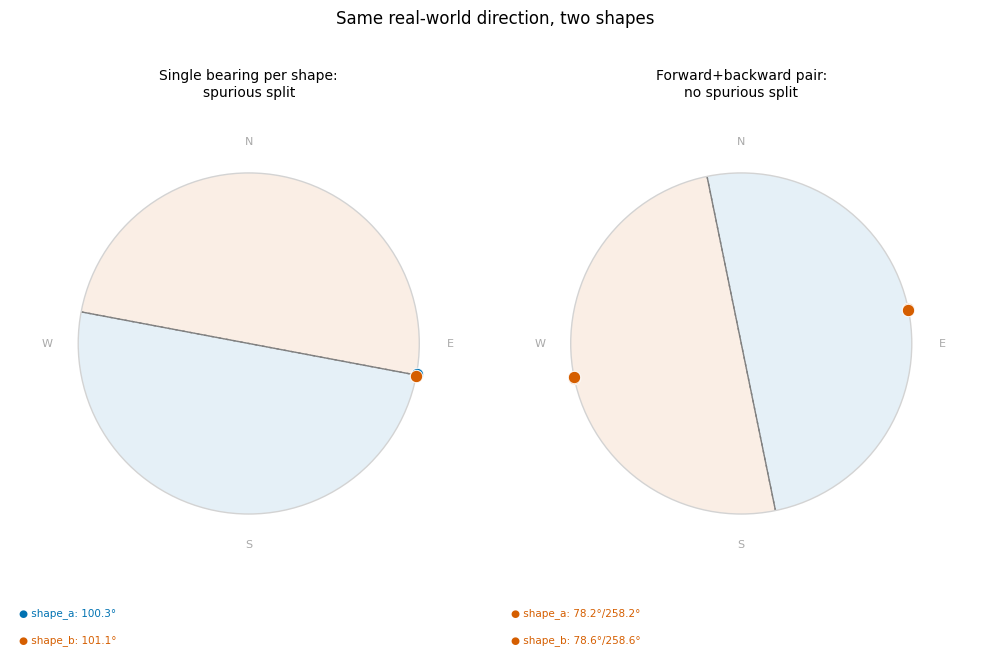

In [4]:
def plot_widest_gap(ax, bearings_by_shape, title):
    plot_widest_gap_compass(ax, bearings_by_shape, title, _split_angle, _widest_gap_split)


# Two shapes going almost exactly the SAME way through a stop (forward
# bearings 0.8 degrees apart -- GPS/geometry noise, not a real split).
same_direction_single_point = {
    "shape_a": [100.27],
    "shape_b": [101.09],
}
same_direction_with_backward = {
    "shape_a": _reconcile_fwd_bwd(100.27, 236.17),
    "shape_b": _reconcile_fwd_bwd(101.09, 236.17),
}

fig, axes = plt.subplots(1, 2, figsize=(10, 6.5), subplot_kw={"aspect": "equal"})
plot_widest_gap(axes[0], same_direction_single_point, "Single bearing per shape:\nspurious split")
plot_widest_gap(axes[1], same_direction_with_backward, "Forward+backward pair:\nno spurious split")
fig.suptitle("Same real-world direction, two shapes", y=1.0)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


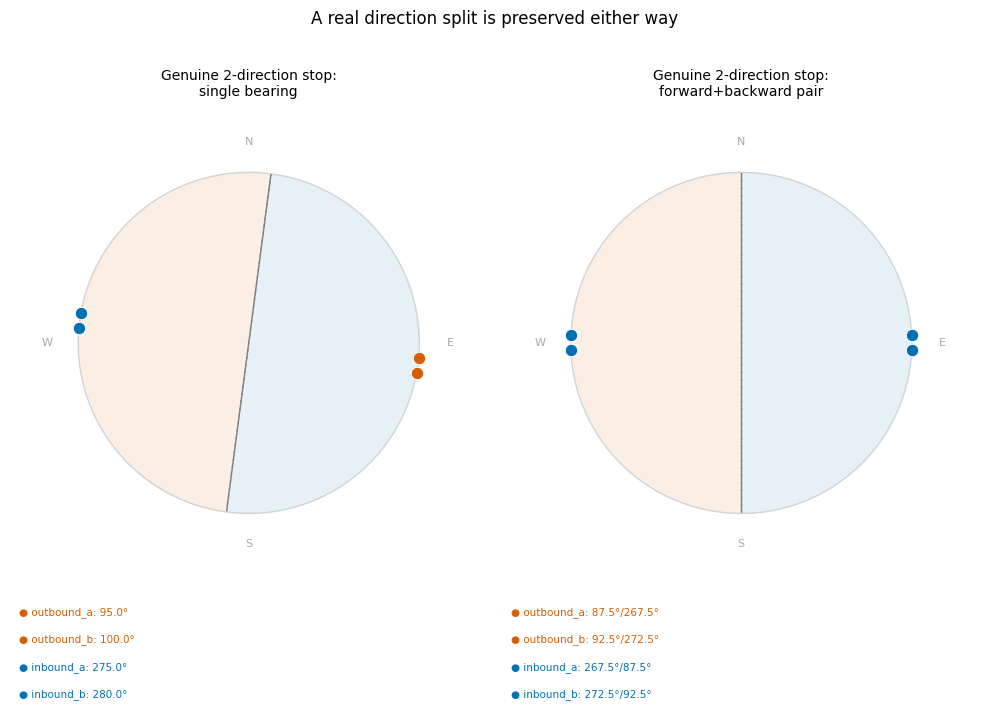

In [5]:
# A genuine two-direction stop (outbound vs inbound), for contrast: the
# widest-gap split correctly separates them either way, single-point or pair.
genuine_split_raw = {
    "outbound_a": [95.0],
    "outbound_b": [100.0],
    "inbound_a": [275.0],
    "inbound_b": [280.0],
}
genuine_split_with_backward = {
    "outbound_a": _reconcile_fwd_bwd(95.0, 260.0),
    "outbound_b": _reconcile_fwd_bwd(100.0, 265.0),
    "inbound_a": _reconcile_fwd_bwd(275.0, 80.0),
    "inbound_b": _reconcile_fwd_bwd(280.0, 85.0),
}

fig, axes = plt.subplots(1, 2, figsize=(10, 7), subplot_kw={"aspect": "equal"})
plot_widest_gap(axes[0], genuine_split_raw, "Genuine 2-direction stop:\nsingle bearing")
plot_widest_gap(axes[1], genuine_split_with_backward, "Genuine 2-direction stop:\nforward+backward pair")
fig.suptitle("A real direction split is preserved either way", y=1.0)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


## 3. From per-stop bins to a route-wide `direction_id`

A stop's 0/1 bin is only meaningful *at that one stop* -- nothing ties "0"
at one stop to "0" at another. `Shapes._assign_direction_ids_for_route`
reconciles this across a whole route:

1. Pick the stop with the most distinct `shape_id`s as the **anchor** --
   its labels become the route's canonical `direction_id`s
2. Walk every other stop (fewest shapes first); at each one, choose
   whichever of {keep local labels, flip them} agrees with more
   already-resolved shapes
3. Once every stop is walked, each `shape_id` is collapsed to a single
   `direction_id`: its own majority value across all of its stops. Any
   stop where that shape's local evidence disagreed with the majority is
   flagged (`direction_conflict=True`) -- a genuine branching ambiguity,
   not a bug. A flagged stop's *actual* local reading is recoverable as
   the other binary value (`1 - direction_id`), which is what
   `maps.conflict_map` shows when you click one.

Sections 5 and 6 below work through this on real synthetic feeds.


## 4. Headway ("mean interval") at stops

`StopsMixin._get_headway_at_stops` summarizes a stop's departure times
within a `[start, end]` window into one "headway" number. It is **not** a
plain average of the gaps between departures -- it's an RMS-style
statistic that penalizes irregular spacing more than a plain average
would.

For sorted departures $d_1 < d_2 < \dots < d_n$ within
$[\text{start}, \text{end}]$, define the wrap-around gap

$$
g_0 = (d_1 - \text{start}) + (\text{end} - d_n)
$$

and the interior gaps $g_i = d_i - d_{i-1}$. Then

$$
\text{headway} = \frac{g_0^2 + \sum_{i=2}^{n} g_i^2}{\text{end} - \text{start}}
$$

- $g_0$ combines the wait before the first departure and the wait after
  the last into a single gap, same treatment as any interior gap
- Squaring (RMS, not mean) makes one big gap plus several tiny ones score
  worse than a perfectly uniform schedule with the same average gap


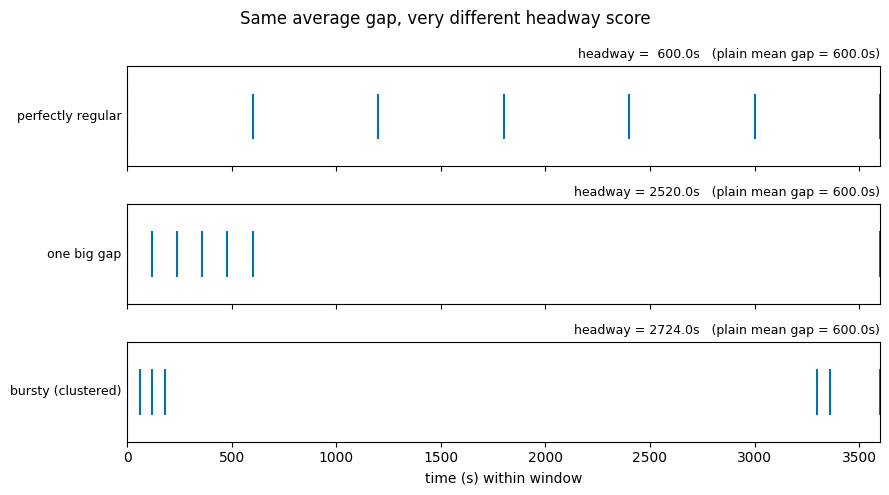

In [6]:
start, end = 0, 3600  # a one-hour window, in seconds

# Three schedules with the SAME average gap (one bus every 10 minutes on
# average, 6 departures in the hour) but very different regularity.
schedules = {
    "perfectly regular": [0, 600, 1200, 1800, 2400, 3000, 3600],
    "one big gap": [0, 120, 240, 360, 480, 600, 3600],
    "bursty (clustered)": [0, 60, 120, 180, 3300, 3360, 3600],
}

fig, axes = plt.subplots(len(schedules), 1, figsize=(9, 5), sharex=True)
for ax, (name, deps) in zip(axes, schedules.items()):
    headway = compute_headway(deps, start, end)
    mean_gap = np.mean(np.diff(sorted(deps)))
    ax.eventplot([deps], lineoffsets=0, linelengths=0.8, colors=CB_BLUE)
    ax.set_xlim(start, end)
    ax.set_yticks([])
    ax.set_ylabel(name, rotation=0, ha="right", va="center", fontsize=9)
    ax.set_title(
        f"headway = {headway:6.1f}s   (plain mean gap = {mean_gap:.1f}s)",
        fontsize=9, loc="right",
    )
axes[-1].set_xlabel("time (s) within window")
fig.suptitle("Same average gap, very different headway score")
plt.tight_layout()
plt.show()


All three schedules have the *same* average gap (600s), but the RMS-style
`headway` formula scores the uneven ones worse than the regular one.


## 5. Worked example -- a genuine `direction_id` conflict

A synthetic feed (`test_files/direction_issue`) built specifically to force
a conflict. Two "original" trips, plus the exact reverse of each, all on
route `R1`:

| trip | stops | shape |
|------|-------|-------|
| T1 | S1 -> S2 -> S3 -> S4 -> S5 -> S6 -> S7 | straight line east |
| T2 | S1 -> S2 -> S8 -> S9 -> S7 -> S6 -> S5 | shares S1/S2 with T1, detours north via S8/S9, re-enters the line at S7, then backtracks through S6 to S5 |
| T3 | S7 -> S6 -> S5 -> S4 -> S3 -> S2 -> S1 | exact reverse of T1 |
| T4 | S5 -> S6 -> S7 -> S9 -> S8 -> S2 -> S1 | exact reverse of T2 |

- With only 2 shapes present at a stop, a conflict is mathematically
  impossible -- splitting always puts them in different bins (2 points
  always define 2 gaps whose midpoints are 180 degrees apart), so
  reconciling "these two differ" across stops is trivial
- A real, unresolvable conflict needs an **odd cycle** in the
  reconciliation graph, which needs at least 3 shapes -- T2's backtrack
  over S6<->S7 (continuing on to S5, so it also collides with T1/T3's
  established S5 pairing, not just S6's) plus its own reverse T4 supplies
  that


In [7]:
for candidate in (Path.cwd() / "test_files" / "direction_issue", Path.cwd() / "examples" / "test_files" / "direction_issue"):
    if candidate.is_dir():
        DATA_DIR = candidate
        break
else:
    raise FileNotFoundError(
        "Could not find test_files/direction_issue relative to the current working "
        f"directory ({Path.cwd()}) -- run this notebook from the repo root or from examples/"
    )

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    feed = Feed(DATA_DIR)
    direction_id_warnings = [w for w in caught if "direction_id assignment" in str(w.message)]

service_date = datetime.date(2026, 8, 3)
start_time = datetime.time(7, 0)
end_time = datetime.time(9, 0)

print(f"{len(direction_id_warnings)} direction_id warning(s) raised during Feed construction:")
for w in direction_id_warnings:
    print(f"  {w.message}")


1 direction_id warning(s) raised during Feed construction:
  direction_id assignment: 2 of 4 shape_ids (50.0%) had at least one stop where the geometry disagreed with their reported direction_id (direction_conflict=True), across 1 of 9 stop(s) (11.1%).


### The raw network

S1-S7 lie on a straight east-west line; S8/S9 are a one-unit-north detour
used only by T2/T4.


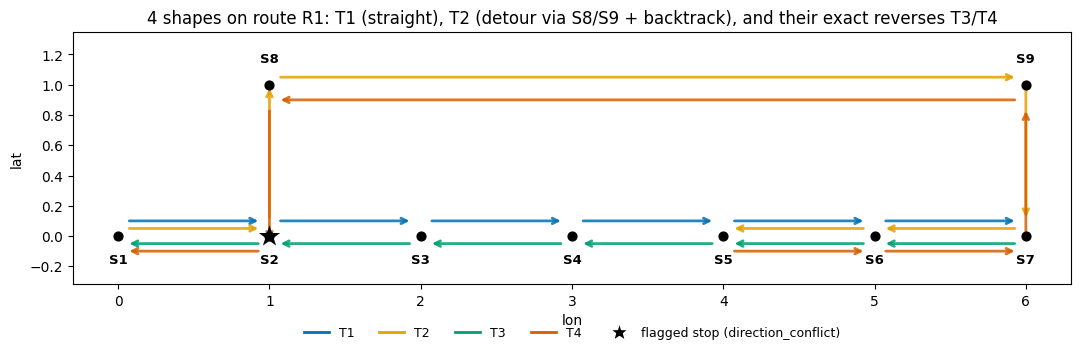

In [8]:
stops_gdf = feed.stops.gdf.copy()
stops_gdf["lon"] = stops_gdf.geometry.x
stops_gdf["lat"] = stops_gdf.geometry.y
stop_coords = dict(zip(stops_gdf["stop_id"], zip(stops_gdf["lon"], stops_gdf["lat"])))

stop_times_df = feed.stop_times.lf.sort(["trip_id", "stop_sequence"]).collect()

# Which stops end up flagged with a genuine direction_id conflict -- shown
# as a star marker below, computed here (rather than lifted from the later
# stop_shapes_df cell) so this plot doesn't depend on notebook cell order.
flagged_stops = set(
    s.split("_file_")[0]
    for s in feed.shapes.stop_shapes.filter(pl.col("direction_conflict")).collect()["stop_id"].unique().to_list()
)

trip_colors = {"T1": CB_BLUE, "T2": CB_ORANGE, "T3": CB_GREEN, "T4": CB_VERMILLION}
# Small per-trip vertical offset so overlapping segments (e.g. all 4 trips
# share S1->S2) are still visible as separate lines.
trip_offsets = {"T1": 0.10, "T2": 0.05, "T3": -0.05, "T4": -0.10}

fig, ax = plt.subplots(figsize=(11, 6))

for trip_id, group in stop_times_df.group_by("trip_id", maintain_order=True):
    trip_id = trip_id[0]
    base_name = trip_id.split("_file_")[0]
    xs = [stop_coords[s][0] for s in group["stop_id"]]
    ys = [stop_coords[s][1] + trip_offsets[base_name] for s in group["stop_id"]]
    color = trip_colors[base_name]
    for i in range(len(xs) - 1):
        ax.annotate(
            "",
            xy=(xs[i + 1], ys[i + 1]),
            xytext=(xs[i], ys[i]),
            arrowprops=dict(arrowstyle="->", color=color, lw=2, alpha=0.85,
                             shrinkA=8, shrinkB=8),
        )
    ax.plot([], [], color=color, lw=2, label=base_name)

# S1-S7 sit on the main line, so their labels go below it; S8/S9 sit north
# of the line, so pushing their labels further north (rather than reusing
# the same downward offset) keeps them clear of the arrows passing beneath.
label_offset = {"S8": (0, 16), "S9": (0, 16)}
for stop_id, (lon, lat) in stop_coords.items():
    base_name = stop_id.split("_file_")[0]
    ax.scatter([lon], [lat], color="black", s=40, zorder=5)
    if base_name in flagged_stops:
        # Shape, not just color, marks a flagged stop -- stays legible
        # under any color vision deficiency.
        ax.scatter([lon], [lat], marker="*", color="black", s=260, zorder=6, linewidth=0)
    ax.annotate(
        base_name, (lon, lat),
        textcoords="offset points", xytext=label_offset.get(base_name, (0, -20)),
        fontsize=9.5, fontweight="bold", ha="center", zorder=7,
        bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.85),
    )

handles, labels = ax.get_legend_handles_labels()
handles.append(plt.Line2D([0], [0], marker="*", color="w", markerfacecolor="black", markersize=14,
                            label="flagged stop (direction_conflict)"))
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=5, fontsize=9, frameon=False)

ax.set_title("4 shapes on route R1: T1 (straight), T2 (detour via S8/S9 + backtrack), and their exact reverses T3/T4")
ax.set_xlabel("lon")
ax.set_ylabel("lat")
ax.set_ylim(-0.32, 1.35)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


### `feed.shapes.stop_shapes`: the reconciled result

`direction_id`/`direction_conflict` are integrated directly into
`stop_shapes`, alongside the untouched raw `shape_direction`/
`shape_direction_backwards` bearings.


In [9]:
stop_shapes_df = (
    feed.shapes.stop_shapes.select(
        [
            "route_id", "shape_id", "stop_id", "stop_sequence",
            "shape_direction", "shape_direction_backwards",
            "direction_id", "direction_conflict",
        ]
    )
    .collect()
    .sort(["stop_id", "shape_id"])
)
stop_shapes_df


route_id,shape_id,stop_id,stop_sequence,shape_direction,shape_direction_backwards,direction_id,direction_conflict
str,str,str,i64,f64,f64,i32,bool
"""R1_file_0""","""T1_file_0""","""S1_file_0""",0,90.0,NaN,1,false
"""R1_file_0""","""T2_file_0""","""S1_file_0""",0,85.026513,NaN,0,false
"""R1_file_0""","""T3_file_0""","""S1_file_0""",6,NaN,90.0,0,false
"""R1_file_0""","""T4_file_0""","""S1_file_0""",6,NaN,85.026513,1,false
"""R1_file_0""","""T1_file_0""","""S2_file_0""",1,90.0,270.0,1,true
…,…,…,…,…,…,…,…
"""R1_file_0""","""T4_file_0""","""S7_file_0""",2,277.130927,270.0,1,false
"""R1_file_0""","""T2_file_0""","""S8_file_0""",2,99.980806,206.566797,0,false
"""R1_file_0""","""T4_file_0""","""S8_file_0""",4,206.566797,99.980806,1,false


Every shape gets exactly **one** `direction_id`, constant across all of its
own stops -- T1 and T3 (the straight line and its exact reverse) are `1`
and `0` respectively everywhere, `direction_conflict` always `False`. T2
and T4 (the detouring pair) are internally consistent too, `direction_conflict`
always `False` for them. It's T1 and T3 that end up flagged: `direction_conflict=True`
at `S2`, the one stop where T1's own local geometry actually agrees with
T2 (same physical direction there) -- contradicting the `direction_id` T1
reports everywhere else, which was anchored from `S6` instead (see section
5's example above for the full mechanism). At that flagged row, T1's
*reported* `direction_id` is its route-wide value; its *actual* local
reading there is the other one.


In [10]:
flagged = stop_shapes_df.filter(pl.col("direction_conflict"))
print(flagged.select(["shape_id", "stop_id", "direction_id"]))

flagged_shape_ids = sorted(s.split("_file_")[0] for s in flagged["shape_id"].unique().to_list())
flagged_stop_ids = sorted(s.split("_file_")[0] for s in flagged["stop_id"].unique().to_list())
print(f"\nFlagged shapes: {flagged_shape_ids}")
print(f"Flagged stops:  {flagged_stop_ids}")


shape: (2, 3)
┌───────────┬───────────┬──────────────┐
│ shape_id  ┆ stop_id   ┆ direction_id │
│ ---       ┆ ---       ┆ ---          │
│ str       ┆ str       ┆ i32          │
╞═══════════╪═══════════╪══════════════╡
│ T1_file_0 ┆ S2_file_0 ┆ 1            │
│ T3_file_0 ┆ S2_file_0 ┆ 0            │
└───────────┴───────────┴──────────────┘

Flagged shapes: ['T1', 'T3']
Flagged stops:  ['S2']


### Plotting the conflict

One arrow per shape at each stop, along its raw bearing, coloured by the
*resolved* `direction_id` (blue = 0, orange = 1). Flagged
`(shape_id, stop_id)` rows are outlined in red.


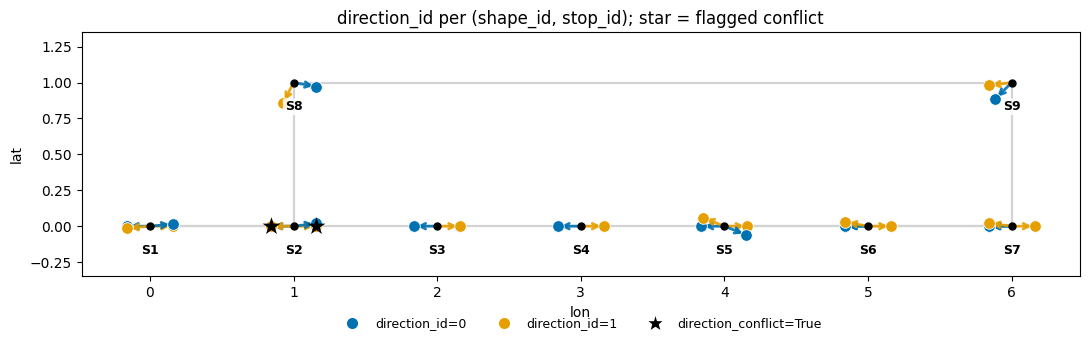

In [11]:
OFFSET_DEG = 0.16
direction_colors = {0: CB_BLUE, 1: CB_ORANGE}

fig, ax = plt.subplots(figsize=(11, 5.5))

# Faint underlay of the raw trip paths for context.
for trip_id, group in stop_times_df.group_by("trip_id", maintain_order=True):
    xs = [stop_coords[s][0] for s in group["stop_id"]]
    ys = [stop_coords[s][1] for s in group["stop_id"]]
    ax.plot(xs, ys, "-", color="lightgray", linewidth=1.5, zorder=1)

for row in stop_shapes_df.iter_rows(named=True):
    lon, lat = stop_coords[row["stop_id"]]
    bearing = row["shape_direction"]
    if bearing is None or bearing != bearing:  # None or NaN (terminal stop)
        bearing = (row["shape_direction_backwards"] + 180) % 360
    bearing_rad = np.deg2rad(bearing)
    dx = np.sin(bearing_rad) * OFFSET_DEG
    dy = np.cos(bearing_rad) * OFFSET_DEG

    color = direction_colors[row["direction_id"]]
    ax.annotate(
        "",
        xy=(lon + dx, lat + dy),
        xytext=(lon, lat),
        arrowprops=dict(arrowstyle="->", color=color, lw=2, alpha=0.9),
        zorder=2,
    )
    ax.scatter([lon + dx], [lat + dy], color=color, s=70, zorder=3, edgecolor="white", linewidth=0.6)
    if row["direction_conflict"]:
        # Shape, not just an outline color, marks a flagged row -- stays
        # legible under any color vision deficiency, and consistent with
        # the flagged-stop marker used earlier in the notebook.
        ax.scatter([lon + dx], [lat + dy], marker="*", color="black", s=180, zorder=4, linewidth=0)

for stop_id, (lon, lat) in stop_coords.items():
    ax.scatter([lon], [lat], color="black", s=25, zorder=4)
    ax.annotate(
        stop_id.split("_file_")[0], (lon, lat),
        textcoords="offset points", xytext=(0, -20), fontsize=9, fontweight="bold", ha="center", zorder=5,
        bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.85),
    )

handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markeredgecolor="white", markersize=9, label=f"direction_id={d}")
    for d, c in direction_colors.items()
]
handles.append(plt.Line2D([0], [0], marker="*", color="w", markerfacecolor="black", markersize=14, label="direction_conflict=True"))
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=9, frameon=False)
ax.set_title("direction_id per (shape_id, stop_id); star = flagged conflict")
ax.set_xlabel("lon")
ax.set_ylabel("lat")
ax.set_ylim(-0.35, 1.35)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


### Takeaways

- T1 and T3 are exact reverses of a simple straight line -- they never
  conflict, at any stop
- T2's backtrack over S6<->S7 is never flagged with only T1/T2 present (2
  shapes can always be reconciled by a single per-stop flip); adding T4
  supplies the shape needed to create an actual contradiction
- The feed-wide warning summarizes this precisely: 2 of 4 shape_ids
  (50.0%) affected, across 3 of 9 stops (33.3%)


## 6. Worked example -- direction split & headway via the public API

A second synthetic feed (`test_files/shape_test`), six stops in a rough "Y"
shape, four trips on route `R1`:

| trip | stops | direction_id | headway |
|------|-------|:---:|:---:|
| T1 | S1 -> S2 -> S3 -> S4 | 0 | 10 min |
| T2 | S4 -> S3 -> S2 -> S1 | 1 | 10 min |
| T3 | S1 -> S2 -> S3 -> S5 -> S6 | 0 | 15 min |
| T4 | S6 -> S5 -> S3 -> S2 -> S1 | 1 | 15 min |

T1/T3 travel "outbound"; T2/T4 are their exact reverse. S2 and S3 are
shared by all four trips.


In [12]:
for candidate in (Path.cwd() / "test_files" / "shape_test", Path.cwd() / "examples" / "test_files" / "shape_test"):
    if candidate.is_dir():
        DATA_DIR = candidate
        break
else:
    raise FileNotFoundError(
        "Could not find test_files/shape_test relative to the current working "
        f"directory ({Path.cwd()}) -- run this notebook from the repo root or from examples/"
    )

feed = Feed(DATA_DIR)

service_date = datetime.date(2026, 8, 3)
start_time = datetime.time(7, 0)
end_time = datetime.time(9, 0)


### The raw network

One line per trip, coloured by `direction_id`. Every stop is a single
point at this stage -- `stops.txt` has no notion of direction.


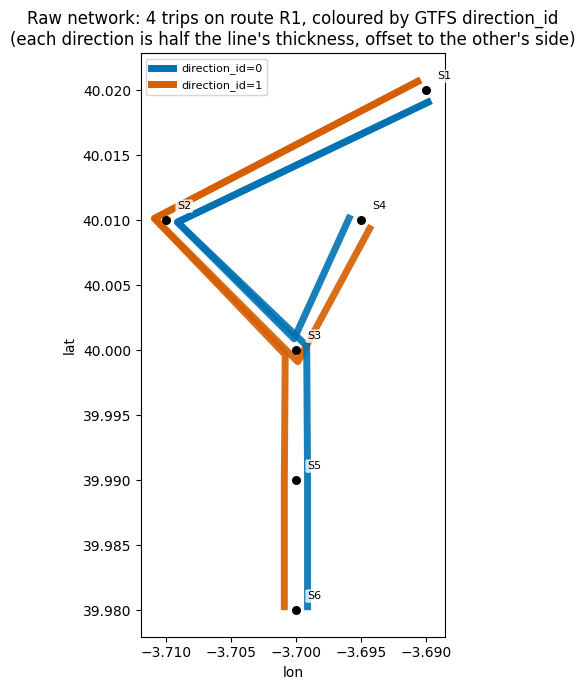

In [13]:
import math

stops_gdf = feed.stops.gdf.copy()
stops_gdf["lon"] = stops_gdf.geometry.x
stops_gdf["lat"] = stops_gdf.geometry.y
stop_coords = dict(zip(stops_gdf["stop_id"], zip(stops_gdf["lon"], stops_gdf["lat"])))

stop_times_df = (
    feed.stop_times.lf.sort(["trip_id", "stop_sequence"]).collect()
)
trips_df = feed.trips.lf.collect()

trip_directions = dict(zip(trips_df["trip_id"], trips_df["direction_id"]))

fig, ax = plt.subplots(figsize=(6, 7))
dir_colors = {0: CB_BLUE, 1: CB_VERMILLION}

# T1/T2 (and T3/T4) are geometrically identical but reversed, so a plain
# plot draws one directly on top of the other. Instead, split the line's
# thickness in half: each direction_id is offset by half the total width,
# perpendicular to the path, so the two halves sit side by side like lane
# markings rather than one hiding the other.
#
# The normal at each vertex comes from a *canonical* (stop_id-sorted) edge
# order, not the trip's own traversal order -- otherwise the reverse
# trip's segment direction flips sign right along with its offset sign,
# and the two cancel out, landing both directions back on the same side.
all_lons = [c[0] for c in stop_coords.values()]
all_lats = [c[1] for c in stop_coords.values()]
bbox_diag = math.hypot(max(all_lons) - min(all_lons), max(all_lats) - min(all_lats))
HALF_OFFSET = 0.02 * bbox_diag


def unit_normal(p_a, p_b):
    dx, dy = p_b[0] - p_a[0], p_b[1] - p_a[1]
    length = math.hypot(dx, dy)
    return (-dy / length, dx / length) if length > 0 else (0.0, 0.0)


def offset_polyline(stop_ids, sign):
    n = len(stop_ids)
    ox, oy = [0.0] * n, [0.0] * n
    for i in range(n):
        normals = []
        if i > 0:
            a, b = sorted((stop_ids[i - 1], stop_ids[i]))
            normals.append(unit_normal(stop_coords[a], stop_coords[b]))
        if i < n - 1:
            a, b = sorted((stop_ids[i], stop_ids[i + 1]))
            normals.append(unit_normal(stop_coords[a], stop_coords[b]))
        nx = sum(v[0] for v in normals) / len(normals)
        ny = sum(v[1] for v in normals) / len(normals)
        norm_len = math.hypot(nx, ny)
        if norm_len > 0:
            nx, ny = nx / norm_len, ny / norm_len
        ox[i], oy[i] = sign * HALF_OFFSET * nx, sign * HALF_OFFSET * ny
    xs = np.array([stop_coords[s][0] for s in stop_ids]) + np.array(ox)
    ys = np.array([stop_coords[s][1] for s in stop_ids]) + np.array(oy)
    return xs, ys


legend_seen = set()
for trip_id, group in stop_times_df.group_by("trip_id", maintain_order=True):
    trip_id = trip_id[0]
    stop_ids = list(group["stop_id"])
    direction_id = trip_directions[trip_id]
    color = dir_colors[direction_id]
    sign = 1 if direction_id == 0 else -1
    oxs, oys = offset_polyline(stop_ids, sign)
    ax.plot(oxs, oys, color=color, linewidth=5, solid_capstyle="butt", alpha=0.9, zorder=2)

    if direction_id not in legend_seen:
        ax.plot([], [], color=color, lw=5, label=f"direction_id={direction_id}")
        legend_seen.add(direction_id)

for stop_id, (lon, lat) in stop_coords.items():
    ax.scatter([lon], [lat], color="black", s=30, zorder=5)
    ax.annotate(
        stop_id.replace("_file_0", ""), (lon, lat),
        textcoords="offset points", xytext=(8, 8), fontsize=8,
        bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.8),
    )

ax.set_title("Raw network: 4 trips on route R1, coloured by GTFS direction_id\n(each direction is half the line's thickness, offset to the other's side)")
ax.set_xlabel("lon")
ax.set_ylabel("lat")
ax.legend(loc="upper left", fontsize=8)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


### Headway grouped by `route_id` / GTFS `direction_id`

`by="route_id"` groups services using the GTFS `route_id` + `direction_id`
columns directly -- this only works because this synthetic feed happens to
set `direction_id` consistently. Many real-world feeds leave it null or
inconsistent, which is exactly the problem the geometric `shape_direction`
method (next section) works around.

`how="all"` returns one row per stop/route/direction combination.


In [14]:
headway_by_route = feed.get_headway_at_stops(
    service_date,
    start_time=start_time,
    end_time=end_time,
    by="route_id",
    at="parent_station",
    how="all",
)

headway_by_route.select(["parent_station", "route_id", "direction_id", "headway"]).sort("parent_station")


parent_station,route_id,direction_id,headway
str,str,i64,f64
"""S1_file_0""","""R1_file_0""",0,8.333333
"""S2_file_0""","""R1_file_0""",0,8.333333
"""S2_file_0""","""R1_file_0""",1,7.533333
"""S3_file_0""","""R1_file_0""",1,7.533333
"""S3_file_0""","""R1_file_0""",0,8.333333
"""S4_file_0""","""R1_file_0""",1,10.0
"""S5_file_0""","""R1_file_0""",0,15.0
"""S5_file_0""","""R1_file_0""",1,15.0
"""S6_file_0""","""R1_file_0""",1,15.0


### Direction split via `shape_direction`

With `by="shape_direction"`, each stop-visit is tagged with a bearing
(degrees from north) computed from the stop's position relative to the
other stops on the same trip pattern -- no `direction_id` and no
`shapes.txt` needed. For every physical stop, the bearings of all its
visits are clustered into `n_divisions * 2` angular bins (`n_divisions=1`
-> forward vs backward) by finding the widest angular gap and splitting on
it (`shape_direction_id`).

A single `stop_id` becomes multiple `(stop_id, shape_direction_id)` rows,
each with its own headway.


In [15]:
from pyGTFSHandler.utils import geo_polars

headway_by_shape = feed.get_headway_at_stops(
    service_date,
    start_time=start_time,
    end_time=end_time,
    by="shape_direction",
    at="stop_id",
    n_divisions=1,
    how="all",
)

split_table = headway_by_shape.select(
    ["stop_id", "shape_direction_id", "shape_direction", "headway", "route_ids"]
).sort(["stop_id", "shape_direction_id"])

# The line separating direction 0 from direction 1 at a stop is
# perpendicular to the (opposing) mean travel bearings observed there --
# recovered here from the per-direction mean bearings, purely for plotting.
split_lines = (
    split_table.group_by("stop_id")
    .agg(pl.col("shape_direction").alias("shape_direction"), pl.len().alias("n_directions"))
)
split_lines = split_lines.with_columns(
    geo_polars.max_separation_angle(split_lines, "shape_direction").alias("split_direction")
)
split_table


stop_id,shape_direction_id,shape_direction,headway,route_ids
str,i32,f64,f64,list[str]
"""S1_file_0""",0,208.688419,8.333333,"[""R1_file_0""]"
"""S2_file_0""",0,185.4845,8.333333,"[""R1_file_0""]"
"""S2_file_0""",1,5.4845,7.533333,"[""R1_file_0""]"
"""S3_file_0""",0,130.791014,8.333333,"[""R1_file_0""]"
"""S3_file_0""",1,310.791014,7.533333,"[""R1_file_0""]"
"""S4_file_0""",0,270.001607,10.0,"[""R1_file_0""]"
"""S5_file_0""",0,360.0,15.0,"[""R1_file_0""]"
"""S5_file_0""",1,180.0,15.0,"[""R1_file_0""]"
"""S6_file_0""",1,0.0,15.0,"[""R1_file_0""]"


In [16]:
# Per-shape_id corrected bearings, before clustering into shape_direction_id
# bins: one row per (shape_id, stop) visit. `shape_direction` is already the
# reconciled forward bearing `_reconcile_fwd_bwd` produces for that shape at
# that stop; the last stop of a shape has no forward bearing, so it falls
# back to the reverse of its backward bearing. `direction_id` (the GTFS
# field) is attached too, for comparison against the geometric
# shape_direction_id clustering below.
shape_bearings = (
    feed.filter(date=service_date, start_time=start_time, end_time=end_time)
    .select(["trip_id", "shape_id", "stop_id", "shape_direction", "shape_direction_backwards"])
    .unique()
    .with_columns(
        pl.when(pl.col("shape_direction").is_finite() & pl.col("shape_direction").is_not_null())
        .then(pl.col("shape_direction"))
        .otherwise((pl.col("shape_direction_backwards") + 180) % 360)
        .alias("corrected_bearing")
    )
    .drop_nulls("corrected_bearing")
    .filter(pl.col("corrected_bearing").is_finite())
    .with_columns(pl.col("trip_id").replace(trip_directions).cast(int).alias("direction_id"))
    .select(["shape_id", "stop_id", "corrected_bearing", "direction_id"])
    .unique()
    .sort(["stop_id", "shape_id"])
    .collect()
)
shape_bearings


shape_id,stop_id,corrected_bearing,direction_id
str,str,f64,i64
"""T1_file_0""","""S1_file_0""",213.832083,0
"""T2_file_0""","""S1_file_0""",33.832083,1
"""T3_file_0""","""S1_file_0""",200.959866,0
"""T4_file_0""","""S1_file_0""",20.959866,1
"""T1_file_0""","""S2_file_0""",117.570458,0
…,…,…,…
"""T2_file_0""","""S4_file_0""",270.001607,1
"""T3_file_0""","""S5_file_0""",180.0,0
"""T4_file_0""","""S5_file_0""",360.0,1


Each row above is one shape's own corrected bearing at one stop --
before any clustering. The plot below adds the clustering boundary on top,
so it's visible *why* the split falls where it does.


### Plotting the split

Two layers:

- **Solid arrows** -- one per `(shape_id, stop_id)` visit, coloured by
  `shape_id`, the *corrected* per-shape bearing (already reconciled by
  `_reconcile_fwd_bwd`)
- **Dashed black line** -- at stops with two direction bins, the angular
  boundary the library uses to decide which cluster a bearing belongs to

(The clustered `shape_direction_id` means and per-stop headways are already
in `split_table`, printed above -- the plot's job here is just to show
*why* the split falls where it does, geometrically.)


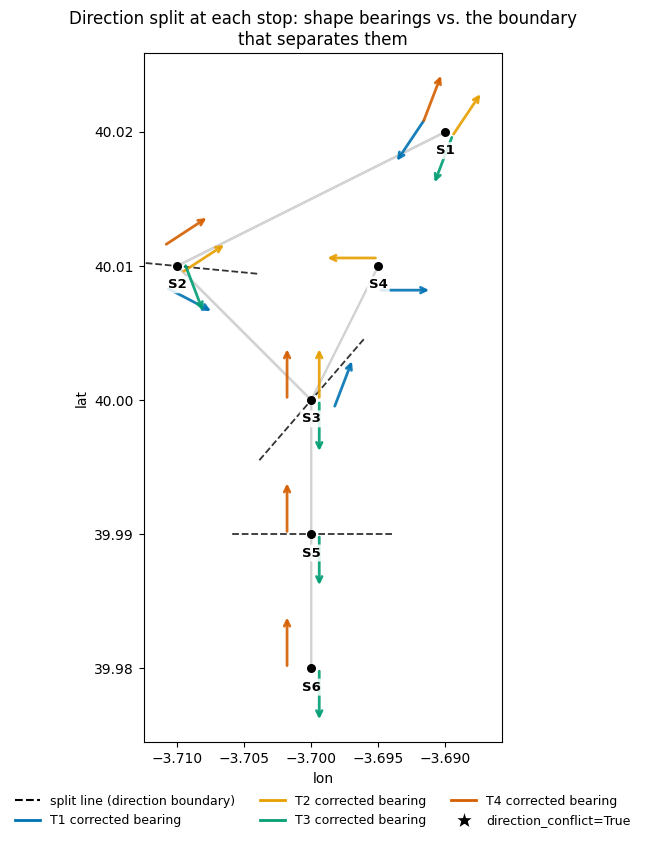

In [17]:
SHAPE_OFFSET_DEG = 0.004  # arrow length for each shape's corrected bearing
LINE_HALF_LEN_DEG = 0.006  # half-length of the split line drawn through each stop
# Perpendicular nudge so shapes with identical bearings at a shared stop
# (e.g. two reverse trips moving backward along the same trunk before
# their branch -- T2/T4 both read ~57 degrees at S2 here) don't draw
# exactly on top of one another; each shape gets a fixed "lane" offset
# instead of a data-dependent one, since these are short, fixed-length
# arrows, not the long offset polylines section 6's other plot needs.
LANE_OFFSET_DEG = 0.0012
shape_ids_sorted = sorted(shape_bearings["shape_id"].unique().to_list())
shape_colors = dict(zip(shape_ids_sorted, [CB_BLUE, CB_ORANGE, CB_GREEN, CB_VERMILLION]))
shape_lane = {sid: i - (len(shape_ids_sorted) - 1) / 2 for i, sid in enumerate(shape_ids_sorted)}

# Which stops have a genuine, unresolved direction_conflict (if any), for
# the star marker below -- consistent with the convention used earlier in
# the notebook (sections 5/6's other plots).
flagged_stops = set(
    s.split("_file_")[0]
    for s in feed.shapes.stop_shapes.filter(pl.col("direction_conflict")).collect()["stop_id"].unique().to_list()
)

fig, ax = plt.subplots(figsize=(7.5, 8.5))

# Faint underlay of the raw trip paths for context.
for trip_id, group in stop_times_df.group_by("trip_id", maintain_order=True):
    xs = [stop_coords[s][0] for s in group["stop_id"]]
    ys = [stop_coords[s][1] for s in group["stop_id"]]
    ax.plot(xs, ys, "-", color="lightgray", linewidth=1.5, zorder=1)

# Split line: dashed, drawn through the stop along split_direction, only
# for stops that actually have two direction bins to separate.
for row in split_lines.filter(pl.col("n_directions") > 1).iter_rows(named=True):
    lon, lat = stop_coords[row["stop_id"]]
    split_rad = np.deg2rad(row["split_direction"])
    ldx = np.sin(split_rad) * LINE_HALF_LEN_DEG
    ldy = np.cos(split_rad) * LINE_HALF_LEN_DEG
    ax.plot(
        [lon - ldx, lon + ldx], [lat - ldy, lat + ldy],
        "--", color="black", linewidth=1.3, zorder=2, alpha=0.8,
    )

# Each shape_id's corrected bearing (already reconciled by
# `_reconcile_fwd_bwd`), colored by shape rather than labelled inline --
# a legend below avoids the label-collision problem entirely, regardless
# of how close together stops or arrows are. Arrow tips are tracked
# separately (`extent_lons`/`extent_lats`) because `ax.annotate` arrows are
# *not* included in matplotlib's autoscale -- without this, a terminal
# stop's arrow pointing "past" the route's actual bounding box (e.g. a
# shape's own last stop, which points onward along its incoming bearing
# even though there's no next stop) gets silently clipped at the axes edge.
extent_lons, extent_lats = [], []
for row in shape_bearings.iter_rows(named=True):
    lon, lat = stop_coords[row["stop_id"]]
    bearing_rad = np.deg2rad(row["corrected_bearing"])
    perp_x, perp_y = -math.cos(bearing_rad), math.sin(bearing_rad)
    lane = shape_lane[row["shape_id"]]
    ox = lon + perp_x * LANE_OFFSET_DEG * lane
    oy = lat + perp_y * LANE_OFFSET_DEG * lane
    dx = np.sin(bearing_rad) * SHAPE_OFFSET_DEG
    dy = np.cos(bearing_rad) * SHAPE_OFFSET_DEG
    color = shape_colors[row["shape_id"]]
    ax.annotate(
        "",
        xy=(ox + dx, oy + dy),
        xytext=(ox, oy),
        arrowprops=dict(arrowstyle="->", color=color, lw=2, alpha=0.9),
        zorder=2,
    )
    extent_lons += [ox + dx, ox]
    extent_lats += [oy + dy, oy]

for stop_id, (lon, lat) in stop_coords.items():
    ax.scatter([lon], [lat], color="black", s=30, zorder=4)
    base_name = stop_id.replace("_file_0", "")
    if base_name in flagged_stops:
        ax.scatter([lon], [lat], marker="*", color="black", s=260, zorder=6, linewidth=0)
    ax.annotate(
        base_name,
        (lon, lat),
        textcoords="offset points",
        xytext=(0, -16),
        fontsize=9.5,
        fontweight="bold",
        ha="center",
        zorder=5,
        bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.85),
    )
    extent_lons.append(lon)
    extent_lats.append(lat)

margin = 0.0015
ax.set_xlim(min(extent_lons) - margin, max(extent_lons) + margin)
ax.set_ylim(min(extent_lats) - margin, max(extent_lats) + margin)

handles = [plt.Line2D([0], [0], linestyle="--", color="black", label="split line (direction boundary)")]
handles += [
    plt.Line2D([0], [0], color=shape_colors[s], lw=2, label=f"{s.replace('_file_0', '')} corrected bearing")
    for s in shape_ids_sorted
]
handles.append(plt.Line2D([0], [0], marker="*", color="w", markerfacecolor="black", markersize=14, label="direction_conflict=True"))
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.06), ncol=3, fontsize=9, frameon=False)
ax.set_title("Direction split at each stop: shape bearings vs. the boundary\nthat separates them", fontsize=12)
ax.set_xlabel("lon")
ax.set_ylabel("lat")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


### Takeaways

- `S3` and `S2` -- shared by both services in both directions -- split into
  two `shape_direction_id` clusters roughly 180 degrees apart, each
  combining the headways of the trips passing that way (harmonic mean, so
  a 10-min and a 15-min service combine to a shorter effective headway than
  either alone)
- Terminal-ish stops (`S1`, `S4`, `S6`) mostly see traffic from one bearing
  per direction bin, so their split mirrors the simpler
  `route_id`/`direction_id` grouping -- but `shape_direction` reaches the
  same conclusion without needing a reliable `direction_id`
- Increasing `n_divisions` (e.g. to 2) splits each stop into 4 angular
  bins instead, useful for junction stops with more than two travel
  directions


### `Shapes.assign_direction_ids`: a route-wide, branch-aware `direction_id`

Sections above used `get_headway_at_stops(by="shape_direction")`, which
clusters bearings independently at each stop -- the resulting
`shape_direction_id` numbering has no relationship from one stop to the
next. `Shapes.assign_direction_ids` builds on the same per-stop bearings
but reconciles them into one consistent `direction_id` per `shape_id`
across an entire route, even through a branch point like `S3` (see
section 3's algorithm).

This is integrated directly into `feed.shapes.stop_shapes`, the same table
used in section 5, now on this feed:


In [18]:
stop_shapes_df = (
    feed.shapes.stop_shapes.select(
        [
            "route_id", "shape_id", "stop_id", "stop_sequence",
            "shape_direction", "shape_direction_backwards",
            "direction_id", "direction_conflict",
        ]
    )
    .collect()
    .sort(["stop_id", "shape_id"])
)
stop_shapes_df


route_id,shape_id,stop_id,stop_sequence,shape_direction,shape_direction_backwards,direction_id,direction_conflict
str,str,str,i64,f64,f64,i32,bool
"""R1_file_0""","""T1_file_0""","""S1_file_0""",0,213.832083,NaN,1,false
"""R1_file_0""","""T2_file_0""","""S1_file_0""",3,NaN,213.832083,0,false
"""R1_file_0""","""T3_file_0""","""S1_file_0""",0,200.959866,NaN,1,false
"""R1_file_0""","""T4_file_0""","""S1_file_0""",4,NaN,200.959866,0,false
"""R1_file_0""","""T1_file_0""","""S2_file_0""",1,117.570458,56.855177,1,false
…,…,…,…,…,…,…,…
"""R1_file_0""","""T2_file_0""","""S4_file_0""",0,270.001607,NaN,0,false
"""R1_file_0""","""T3_file_0""","""S5_file_0""",3,180.0,360.0,1,false
"""R1_file_0""","""T4_file_0""","""S5_file_0""",1,360.0,180.0,0,false


Unlike `shape_direction_id` above, `direction_id` here is `1` for every one
of T1/T3's stops and `0` for every one of T2/T4's, including at the S3
junction, with `direction_conflict` `False` on every row -- no conflicts
on this route.


## 7. On a real feed: conflict map + headway-colored route map

Everything above used tiny synthetic feeds to isolate one mechanism at a
time. To close out, the same tools on a real network -- the combined
Sevilla feeds (Metro Sevilla + TUSSAM).


In [19]:
OUTPUT_DIR = Path("outputs/direction_and_headway_methodology")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR = Path("test_files/madrid")
feed = Feed(DATA_DIR / "20260729_100039_CRTM_Autobuses_Interurbanos", stop_group_distance=100)
service_date = datetime.date(2026, 8, 10)


/home/miguel/Documents/Proyectos/pyGTFSHandler/pyGTFSHandler/models/shapes.py:1285: RuntimeWarning: direction_id assignment: 130 of 3053 shape_ids (4.3%) had at least one stop where the geometry disagreed with their reported direction_id (direction_conflict=True), across 351 of 6651 stop(s) (5.3%).
  warnings.warn(


### `direction_id` conflicts

`conflict_map` draws every stop with at least one
`direction_conflict=True` row as a red marker; every other stop is a
small gray dot. Clicking a red stop lists the conflicting `route_id`s;
clicking a route shows its conflicting `shape_id`s there, alongside the
longest non-conflicting `shape_id` of that route as a reference. Since
`direction_id` is now one constant value per `shape_id` (see section 3),
a conflicting shape's own numbered stop markers additionally get a small
star at the specific stop(s) where the geometry actually disagreed with
that reported value -- clicking a starred stop shows both the reported
`direction_id` and the differing "real" local direction the geometry
there indicated.


In [20]:
from pyGTFSHandler.maps import conflict_map

m = conflict_map(feed)
m.save(str(OUTPUT_DIR / "conflict_map.html"))
m


[output too large to embed in the docs site -- run this notebook locally or in Colab to view it]

### Route map, stops colored by headway

The interactive `route_map` already has a built-in "Color by" -> Headway
toggle. Here's the same idea built by hand, outside the map: each stop's
route-type emoji plotted in grayscale, black for the most frequent
service (lowest headway) and white for the least frequent, using the mean
headway across all routes serving that stop's `parent_station`.


In [21]:
from pyGTFSHandler.maps.style import route_type_emoji

station_headway = feed.get_headway_at_stops(
    service_date,
    by="route_id",
    at="parent_station",
    how="mean",  # combine all routes serving the station into one number
)

# One route_type per station, for the emoji glyph (a station can be served
# by more than one mode; pick the most frequent one there).
station_route_type = (
    feed.filter(date=service_date)
    .group_by("parent_station")
    .agg(pl.col("route_type").mode().first().alias("route_type"))
    .collect()
)
station_headway = station_headway.join(station_route_type, on="parent_station", how="left")
station_headway = feed.add_stop_coords(station_headway)
station_headway.head()


direction_id,parent_station,route_ids,shape_direction,shape_direction_backwards,headway,route_type,stop_lat,stop_lon,stop_name
i64,str,list[str],f64,f64,f64,i64,f64,f64,str
1,"""par_8_18740_file_0""","[""8__182____file_0""]",209.157897,41.419256,1439.983333,3,40.753609,-3.412123,"""CTRA.VALDENUnO-CRUCE_MESONES"""
0,"""par_8_20289_file_0""","[""8__496____file_0""]",333.263415,81.158706,128.292365,3,40.261192,-3.913074,"""B.PeREZ_GALDoS-GOYA"""
0,"""par_8_17442_file_0""","[""8__488____file_0""]",115.144349,317.95396,128.287399,3,40.322334,-3.737646,"""AV.SALVADOR_ALLENDE-URUGUAY"""
1,"""par_8_12546_file_0""","[""8__194_A___file_0""]",0.582617,235.25969,289.735634,3,40.990061,-3.638375,"""AV.MADRID-CENTRO_DE_ESTUDIOS"""
1,"""par_8_06198_file_0""","[""8__627____file_0""]",96.951361,200.287909,241.541238,3,40.485485,-3.97313,"""CTRA.M509-LOS_PINOS"""


In [22]:
headway = station_headway["headway"].to_numpy()
norm = plt.Normalize(vmin=np.nanmin(headway), vmax=np.nanmax(headway))
cmap = plt.cm.gray  # 0 (frequent) = black, 1 (infrequent) = white

fig, ax = plt.subplots(figsize=(9, 9))
ax.set_facecolor("lightsteelblue")  # so white (infrequent) emojis stay visible

for row in station_headway.iter_rows(named=True):
    color = cmap(norm(row["headway"]))
    ax.text(
        row["stop_lon"], row["stop_lat"],
        route_type_emoji(row["route_type"]),
        fontsize=11, ha="center", va="center", color=color,
    )

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, ax=ax, label="mean headway at parent_station (minutes)", shrink=0.7)
ax.set_title("Sevilla stops, colored by mean headway (black = frequent, white = infrequent)")
ax.set_xlabel("lon")
ax.set_ylabel("lat")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


/tmp/ipykernel_201865/23500014.py:22: UserWarning: Glyph 128652 (\N{BUS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/tmp/ipykernel_201865/23500014.py:22: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


/home/miguel/Documents/Proyectos/pyGTFSHandler/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128652 (\N{BUS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


[output too large to embed in the docs site -- run this notebook locally or in Colab to view it]